# NorESM Binned CCN–CDNC Susceptibility

**Scientific question:** How does CCN–CDNC susceptibility vary with CCN cutoff radius when the relationship is estimated by **binning CCN into log-spaced bins** and regressing bin-mean CDNC on bin-mean CCN? Binning suppresses sampling noise and exposes the mean response; the regression standard error gives a 95% CI.

CDNC is masked to in-cloud points (`FREQL > 0.8`). Susceptibility is the slope in log–log space, so the bin averaging is done on **log-transformed** values (geometric mean), not linear means — see Section 3.

**Input:** per-station NorESM/OsloAero file.  
**Output:** `reg_ds` (slope, r_value, std_err per station/radius), optionally saved.

---
*Sections: 1 Setup · 2 Load & cloud-mask · 3 Bin & regress · 4 Plots · 5 Save.*

## 1 · Setup and configuration

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
# Configuration
NOR_PATH = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
RADII    = np.logspace(0, 2.7, 31)     # CCN cutoff radii [nm], ~1 to 500 nm
VAR_LIST = ['FREQL', 'Z3']             # cloud fraction + geopotential height
D_GRID   = xr.DataArray(np.logspace(-0.5, 6, num=200), dims=['D'],
                        coords={'D': np.logspace(-0.5, 6, num=200)})
CCN_BINS = np.logspace(0, 4, 101)      # log-spaced CCN bins (linear CCN units)
ds = xr.open_dataset(f'{NOR_PATH}', engine='netcdf4')  # to store results for all stations
# Optional: where to save reg_ds at the end (set to None to skip saving)
SAVE_PATH = None  # e.g. '/share/pech2273/NorESM_Susceptibility_Binned.nc'

## 2 · Load, build CCN, and cloud-mask CDNC

`CCN_CDNC_Dataset` aligns and packages CCN and CDNC. The build loop integrates the aerosol size distribution into CCN per cutoff radius (`NorERF`), masks CDNC to in-cloud points (`FREQL > 0.8`), and stacks all stations. `.compute()` materializes the result for the binning loop.

In [9]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """Align CCN(radius, lev, time) and CDNC(lev, time) and package together."""
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)
    return xr.Dataset(
        data_vars={'CCN': CCN_aligned, 'CDNC': CDNC_aligned},
        coords={'radius': CCN_aligned.radius,
                'lev': CCN_aligned.lev,
                'time': CCN_aligned.time},
    )

In [10]:
all_stationsCCN = []
all_stationsHeight = []

for station in ds['station'].values:
    Nor_ds = Function.NorESMExtract_Dask(NOR_PATH, station, VAR_LIST, D_GRID, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, RADII)
    height = Nor_ds['Z3'].mean('time')

    # Mask CDNC to in-cloud points (cloud fraction > 0.8)
    Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL'] > 0.8))

    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))
    all_stationsHeight.append(height.assign_coords(station=station))

CCN_all    = xr.concat(all_stationsCCN, dim='station').compute()
Height_all = xr.concat(all_stationsHeight, dim='station')

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## 3 · Bin by CCN and regress (log-space averaging)

For each (station, radius): bin both CCN and CDNC by CCN value, then average the **log10-transformed** values within each bin and OLS-fit. 

**Why log-first:** susceptibility is a log–log slope, so the correct per-bin summary is the geometric mean (mean of logs), not the arithmetic mean of the raw values. Averaging in linear space and then logging biases the bin points upward (Jensen's inequality on skewed, ~lognormal CCN/CDNC) and distorts the slope. Binning is still keyed on the original linear CCN values so the bins match `CCN_BINS`.

In [11]:
stations = CCN_all.station.values

reg_ds = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(RADII)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(RADII)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(RADII)), np.nan)),
    },
    coords={"station": stations, "radius": RADII},
)

for s, station in enumerate(stations):
    for r in range(len(RADII)):
        CCN_slice  = CCN_all['CCN'].sel(station=station).isel(radius=r)
        CDNC_slice = CCN_all['CDNC'].sel(station=station)

        # log-transform FIRST (guard against <=0 -> -inf), then average within bins.
        # Group on the ORIGINAL linear CCN so bins line up with CCN_BINS edges.
        logCCN  = np.log10(CCN_slice.where(CCN_slice > 0))
        logCDNC = np.log10(CDNC_slice.where(CDNC_slice > 0))

        x = logCCN.groupby_bins(CCN_slice, CCN_BINS).mean().values
        y = logCDNC.groupby_bins(CCN_slice, CCN_BINS).mean().values

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 2:
            continue  # too few populated bins to fit

        slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
        reg_ds['slope'][s, r]   = slope
        reg_ds['r_value'][s, r] = r_value
        reg_ds['std_err'][s, r] = std_err

## 4 · Plots

### 4a · Single station (SMR-II) with 95% confidence band

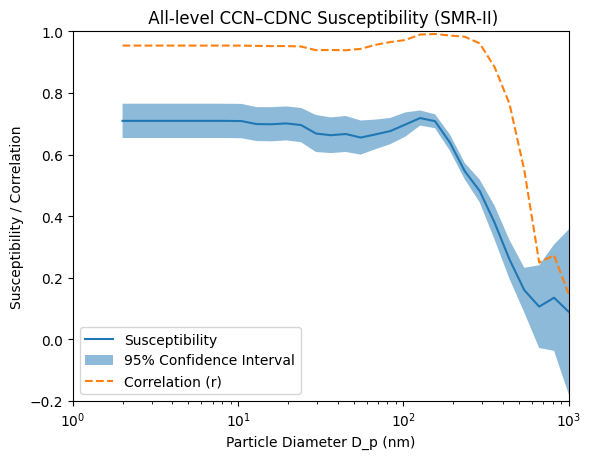

In [12]:
plt.plot(RADII*2, reg_ds['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(RADII*2,
                 reg_ds['slope'].sel(station = 'SMR-II')-1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 reg_ds['slope'].sel(station = 'SMR-II')+1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(RADII*2, reg_ds['r_value'].sel(station = 'SMR-II'), '--', label = 'Correlation (r)')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (SMR-II)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

### 4b · All stations grid

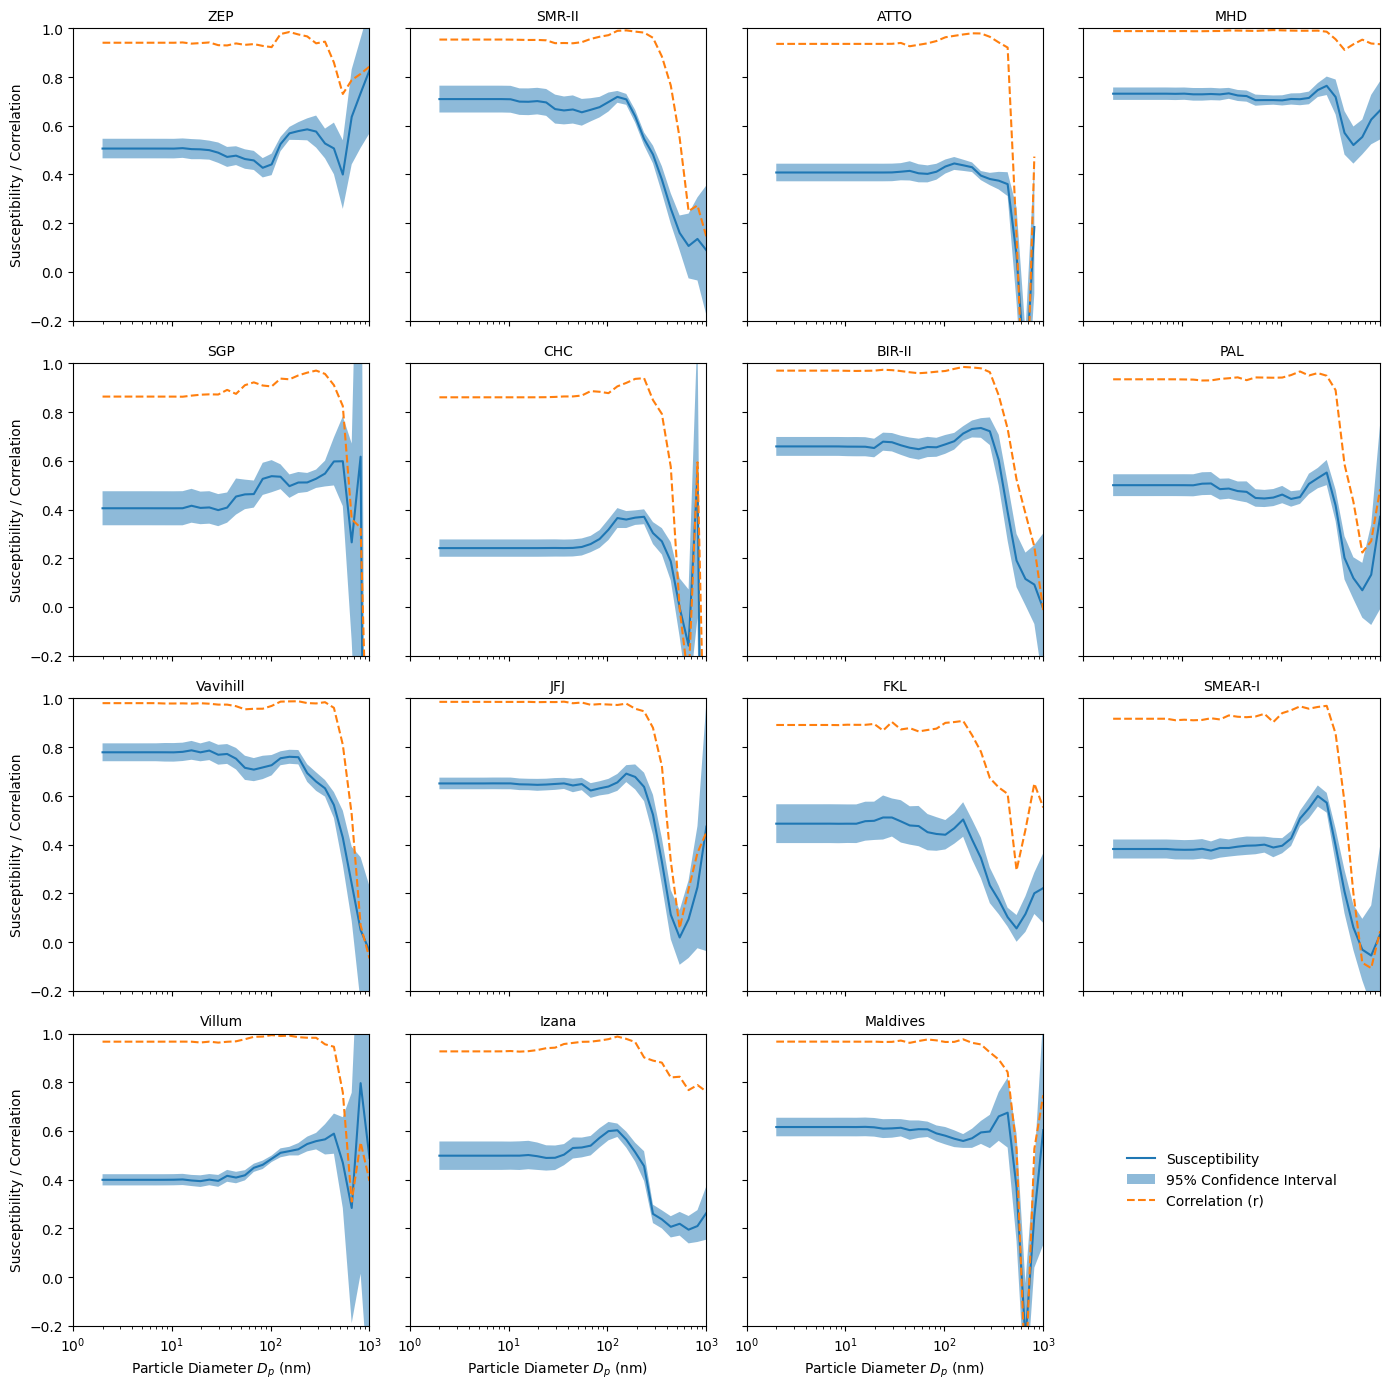

In [13]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(RADII * 2, slope, label='Susceptibility')
    ax.fill_between(
        RADII * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        RADII * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



### 4c · Binned scatter diagnostic (SMR-II, one radius)

Shows the binned points the fit actually uses. Averaging is done in **log space** here too (geometric mean), so this plot is consistent with the Section-3 slopes. Error bars are the within-bin std of the logged values.

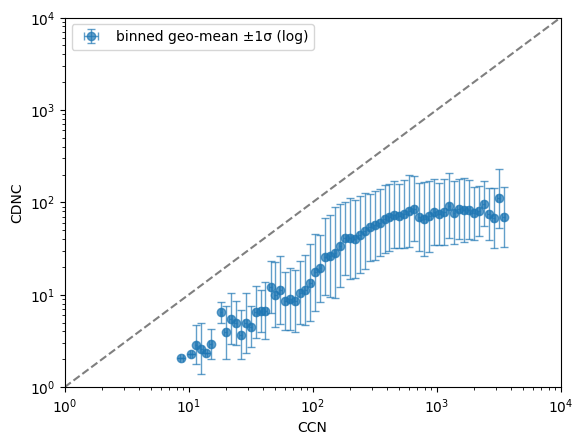

In [14]:
st, ridx = 'SMR-II', 1
ccn  = CCN_all['CCN'].sel(station=st).isel(radius=ridx)
cdnc = CCN_all['CDNC'].sel(station=st)

logCCN  = np.log10(ccn.where(ccn > 0))
logCDNC = np.log10(cdnc.where(cdnc > 0))

# geometric-mean bin points (in log space), converted back to linear for plotting
x_log = logCCN.groupby_bins(ccn, CCN_BINS).mean()
y_log = logCDNC.groupby_bins(ccn, CCN_BINS).mean()
x_err = logCCN.groupby_bins(ccn, CCN_BINS).std()
y_err = logCDNC.groupby_bins(ccn, CCN_BINS).std()

plt.errorbar(10**x_log, 10**y_log,
             xerr=[10**x_log - 10**(x_log - x_err), 10**(x_log + x_err) - 10**x_log],
             yerr=[10**y_log - 10**(y_log - y_err), 10**(y_log + y_err) - 10**y_log],
             fmt='o', capsize=3, elinewidth=1, alpha=0.7, label='binned geo-mean ±1σ (log)')
plt.xscale('log'); plt.yscale('log')
plt.xlim([1, 1e4]); plt.ylim([1, 1e4])
plt.plot([1, 1e4], [1, 1e4], 'k--', alpha=0.5)
plt.xlabel('CCN'); plt.ylabel('CDNC'); plt.legend(); plt.show()

## 5 · Save results (optional)

Persist `reg_ds` so downstream notebooks (e.g. clustering) can load it without re-running the expensive binning. Set `SAVE_PATH` in Section 1 to enable.

In [15]:
if SAVE_PATH is not None:
    reg_ds.to_netcdf(SAVE_PATH)
    print('saved ->', SAVE_PATH)
else:
    print('SAVE_PATH is None; not saving. Set it in Section 1 to persist reg_ds.')

SAVE_PATH is None; not saving. Set it in Section 1 to persist reg_ds.
